In [9]:
#parameters

### USER EDIT start
# esm_file='/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json'
esm_file='/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/experiment_datastore.json'
dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-om3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/experiment_datastore.json
Plot folder path:  /g/data/ps29/nd0349/access-om3-paper-figs/


In [10]:
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import cftime
import os
import matplotlib.pyplot as plt
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
from textwrap import wrap
xr.set_options(keep_attrs=True);  # cf_xarray works best when xarray keeps attributes by default

In [11]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33871 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/33871/status,
Dashboard: /proxy/33871/status,Workers: 4
Total threads: 4,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35331,Workers: 0
Dashboard: /proxy/33871/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37383,Total threads: 1
Dashboard: /proxy/35429/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:46629,


### Define plot function

In [12]:
blue_marble = plt.imread('/g/data/ik11/grids/BlueMarble.tiff')
blue_marble_extent = (-180, 180, -90, 90)

In [13]:
# def plot(dat, title=None, **kwargs):
#     if title is None:
#         title = dat.attrs['long_name']
#     fig = plt.figure(figsize=(12, 6))
#     ax = plt.axes(projection=ccrs.Robinson(central_longitude=-100))
#     dat.plot.contourf(
#         ax=ax,
#         transform=ccrs.PlateCarree(),
#         cbar_kwargs={"label": "\n".join(wrap(f"{dat.attrs['long_name']} [{dat.attrs['units']}]", 45)),
#                      "fraction": 0.03, "aspect": 15, "shrink": 0.7},
#         **kwargs
#     )
    
#     # Add blue marble land:
#     ax.imshow(
#         blue_marble, extent=blue_marble_extent, transform=ccrs.PlateCarree(), origin="upper"
#     )
    
#     plt.title(title);

### Load and plot data from ACCESS-OM3

In [14]:
exptname = os.path.basename(os.path.dirname(esm_file))

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
    ]
)

In [15]:
exptname

'MCW_100km_jra_iaf_IC4_KPP'

In [16]:
geolon = datastore.search(variable="geolon", file_id='access_om3_mom6_static').to_dask().geolon
geolat = datastore.search(variable="geolat", file_id='access_om3_mom6_static').to_dask().geolat

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [17]:
variable = "tos"
sst = datastore.search(variable=variable, frequency="1day").to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
)[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

In [18]:
sst

<xarray.DataArray 'tos' (time: 365, yh: 300, xh: 360)> Size: 158MB
dask.array<concatenate, shape=(365, 300, 360), dtype=float32, chunksize=(31, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1958-01-01T12:00:00 ... 1958-12-31T12:...
    yh       (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    xh       (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    units:          degC
    long_name:      Sea Surface Temperature
    cell_methods:   area:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_surface_temperature

In [19]:
geolon

<xarray.DataArray 'geolon' (yh: 300, xh: 360)> Size: 864kB
dask.array<open_dataset-geolon, shape=(300, 360), dtype=float64, chunksize=(300, 360), chunktype=numpy.ndarray>
Coordinates:
  * yh       (yh) float64 2kB -77.88 -77.63 -77.38 -77.13 ... 88.87 89.32 89.77
  * xh       (xh) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
Attributes:
    units:         degrees_east
    long_name:     Longitude of tracer (T) points
    cell_methods:  time: point

In [22]:
variable = "HS"
swh = datastore.search(variable=variable, frequency="fx").to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
).rename({'ny': 'yh', 'nx': 'xh'})[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

In [23]:
swh

<xarray.DataArray 'HS' (time: 365, yh: 300, xh: 360)> Size: 158MB
dask.array<concatenate, shape=(365, 300, 360), dtype=float32, chunksize=(1, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 3kB 1958-01-02 1958-01-03 ... 1959-12-01
  * yh         (yh) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xh         (xh) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
    latitude   (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    units:      m
    long_name:  Significant wave height

In [24]:
variable = "aice"
aice = datastore.search(variable=variable, frequency="1day").to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
).rename({'nj': 'yh', 'ni': 'xh'})[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

In [25]:
aice

<xarray.DataArray 'aice' (time: 365, yh: 300, xh: 360)> Size: 315MB
dask.array<concatenate, shape=(365, 300, 360), dtype=float64, chunksize=(31, 150, 180), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 3kB 1958-01-01T12:00:00 ... 1958-12-31T1...
  * yh         (yh) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xh         (xh) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
    latitude   (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    units:          1
    long_name:      ice area  (aggregate)
    cell_measures:  area: tarea
    cell_methods:   time: mean
    time_rep:       averaged

In [52]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def make_fig(central_longitude=0, central_latitude=0):
    fig = plt.figure(figsize=(8, 8))

    # Define the three Orthographic projections
    proj_top = ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
    proj_left = ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)
    proj_right = ccrs.Orthographic(central_longitude=central_longitude, central_latitude=central_latitude)

    # Axes positions: (left, bottom, width, height)
    ax_top = fig.add_axes([0.3, 0.55, 0.4, 0.4], projection=proj_top)
    ax_left = fig.add_axes([0.05, 0.05, 0.4, 0.4], projection=proj_left)
    ax_right = fig.add_axes([0.55, 0.05, 0.4, 0.4], projection=proj_right)

    axes = [ax_top, ax_left, ax_right]

    for ax in axes:
        ax.set_global()
        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.OCEAN, facecolor="white")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.gridlines(draw_labels=False, linewidth=0.5, linestyle=":")

    return fig, axes

Text(0.5, 1.0, 'CICE6')

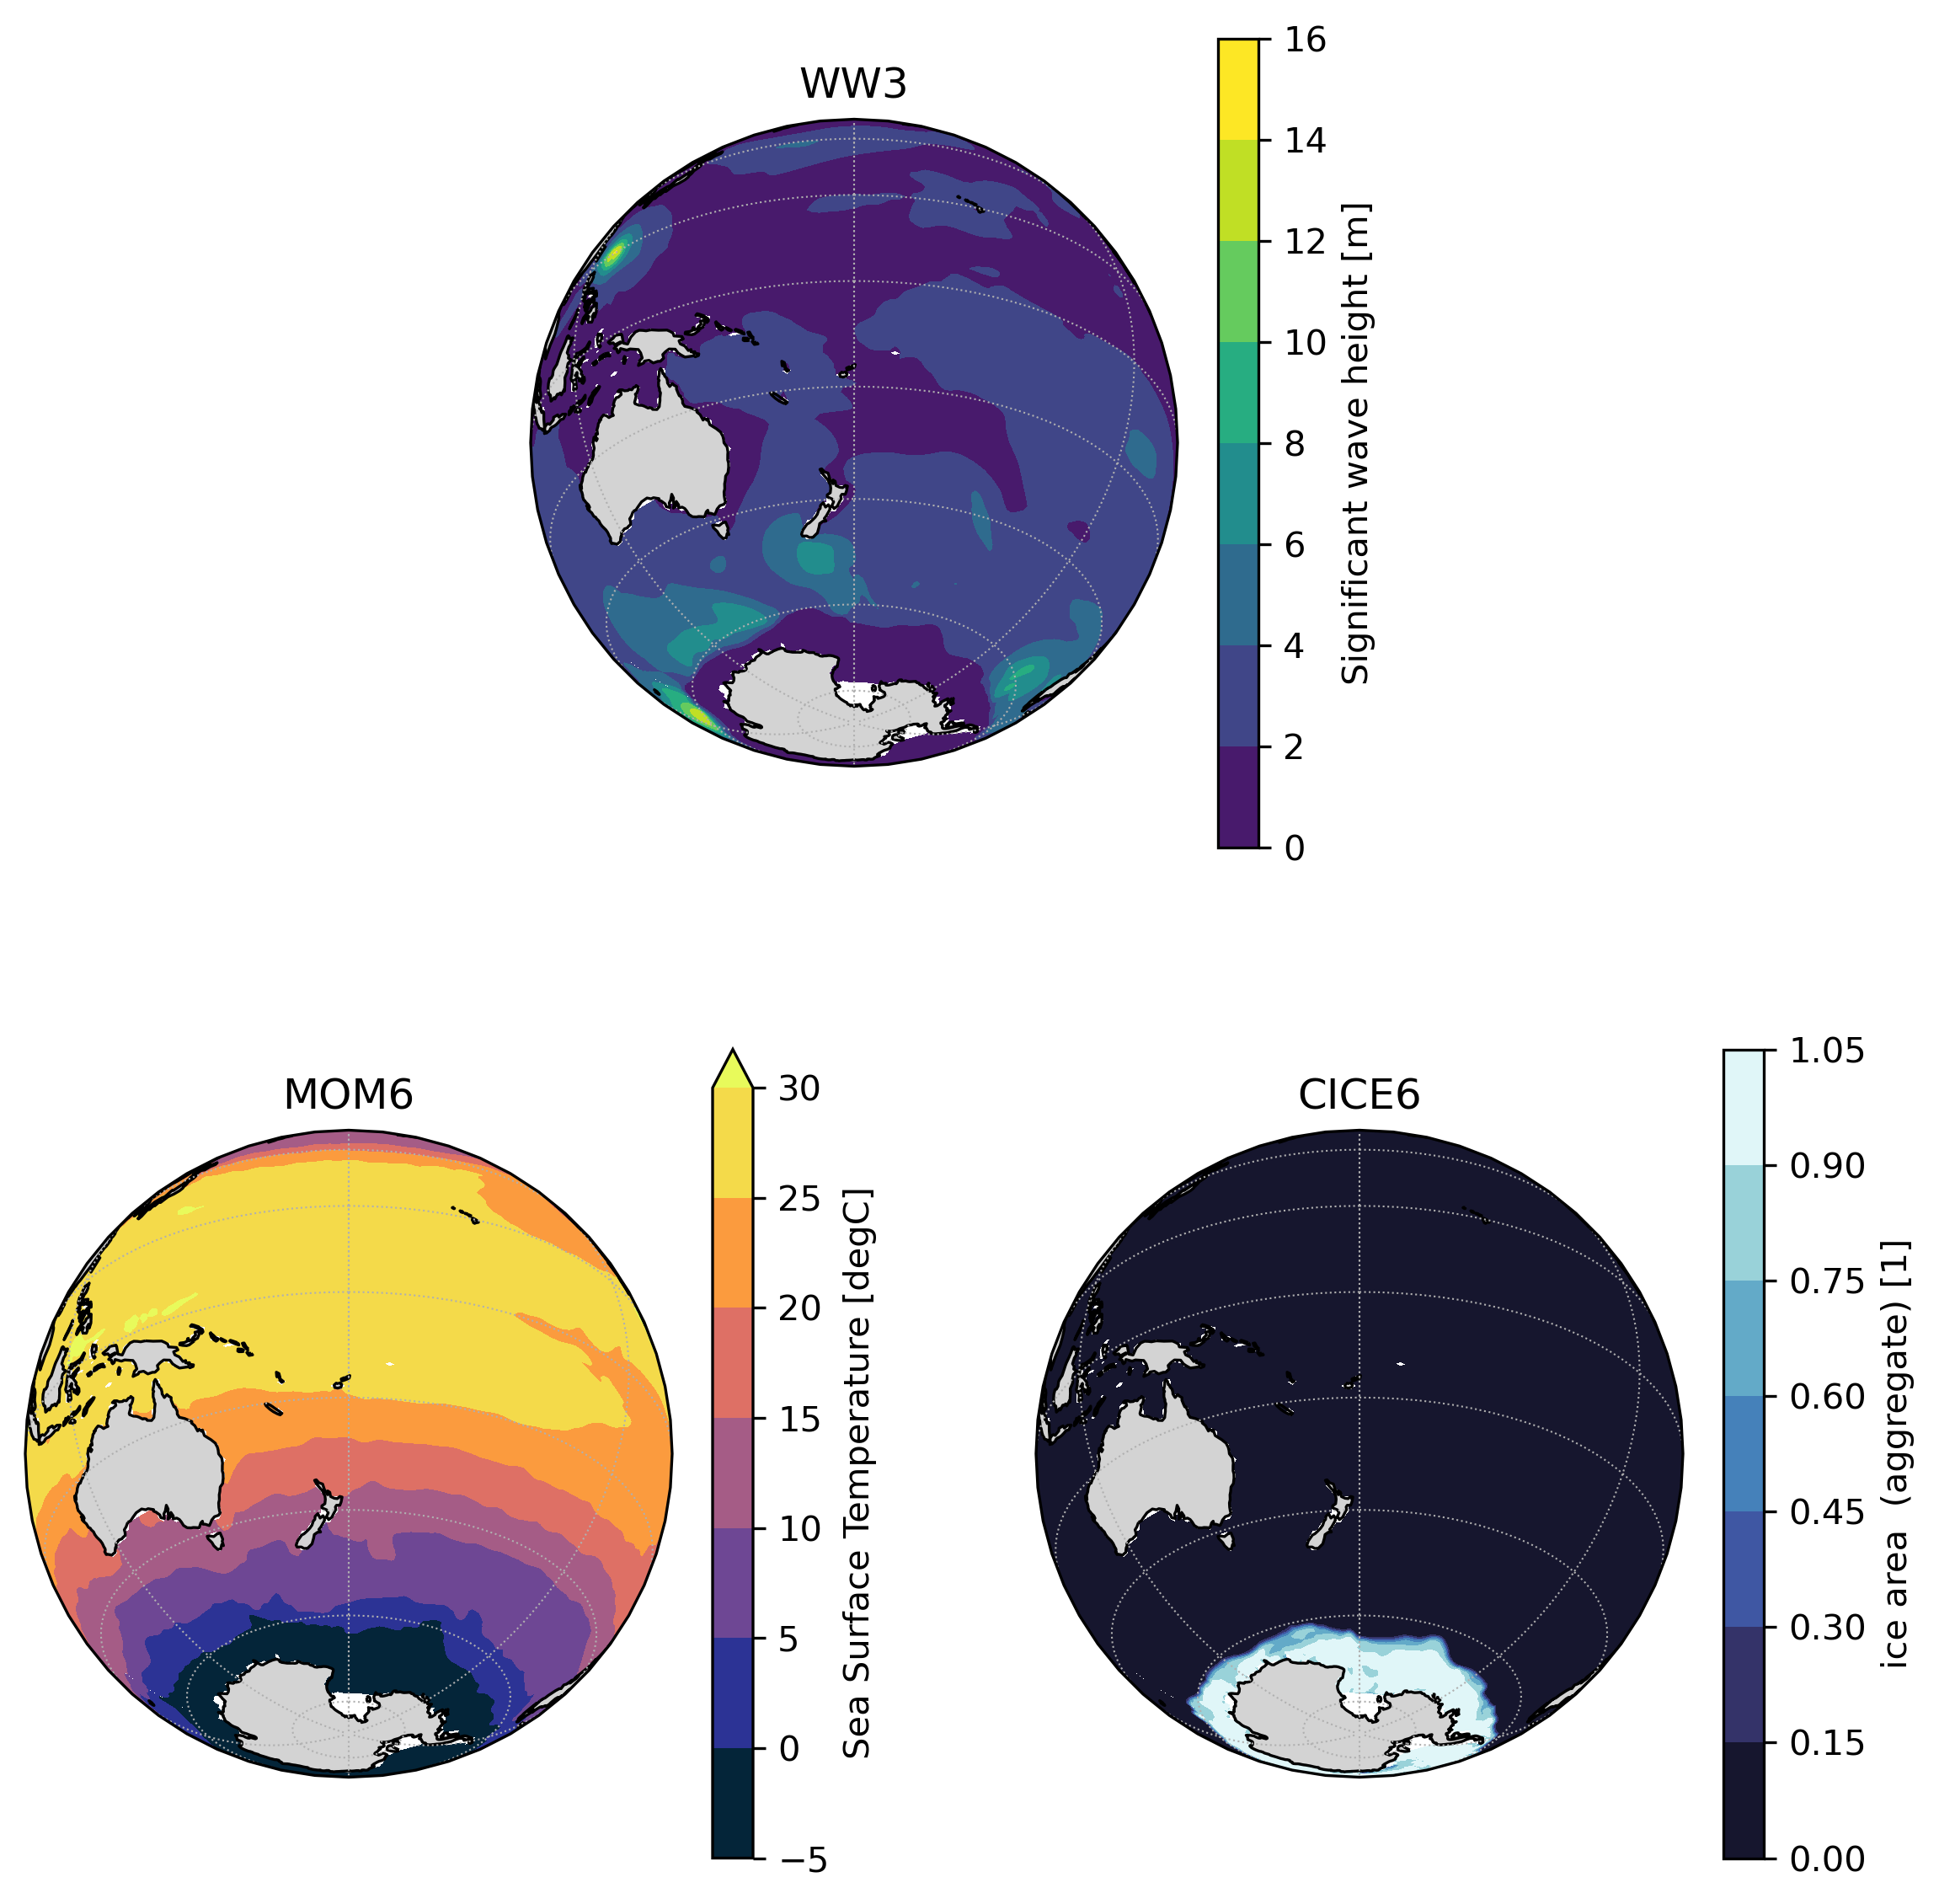

In [53]:
time_idx = 243

fig, axes = make_fig(central_longitude=180, central_latitude=-30)

swh.isel(time=time_idx).plot.contourf(
    ax=axes[0],
    transform=ccrs.PlateCarree()
)
axes[0].set_title('WW3')

sst.isel(time=time_idx).plot.contourf(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    vmin=-3,
    vmax=30,
    cmap=cm.cm.thermal
)
axes[1].set_title('MOM6')

aice.isel(time=time_idx).plot.contourf(
    ax=axes[2],
    transform=ccrs.PlateCarree(),
    cmap=cm.cm.ice
)
axes[2].set_title('CICE6')

In [5]:
figpath = "/g/data/ps29/nd0349/access-om3-paper-figs/gif/frames"
os.makedirs(figpath, exist_ok=True)


In [54]:

times = swh.time.size
longitudes = np.linspace(0, 360, times, endpoint=False)

for i, (time_idx, clon) in enumerate(zip(range(times), longitudes)):

    fig, axes = make_fig(
        central_longitude=clon,
        central_latitude=-30
    )

    swh.isel(time=time_idx).plot.contourf(
        ax=axes[0],
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )
    axes[0].set_title("WW3")

    sst.isel(time=time_idx).plot.contourf(
        ax=axes[1],
        transform=ccrs.PlateCarree(),
        vmin=-3,
        vmax=30,
        cmap=cm.cm.thermal,
        add_colorbar=False
    )
    axes[1].set_title("MOM6")

    aice.isel(time=time_idx).plot.contourf(
        ax=axes[2],
        transform=ccrs.PlateCarree(),
        cmap=cm.cm.ice,
        add_colorbar=False
    )
    axes[2].set_title("CICE6")

    outfile = os.path.join(figpath, f"MCW_frame_{i:04d}.png")
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [8]:
import imageio.v2 as imageio

pattern = os.path.join(figpath, "MCW_frame_*.png")
files = sorted(glob.glob(pattern))

images = [imageio.imread(f) for f in files]

imageio.mimsave(
    os.path.join(figpath, f"MCW_coupling.gif"),
    images,
    fps=20
)

In [66]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def make_fig_antarctica(central_longitude=0):
    fig = plt.figure(figsize=(8, 5))

    proj = ccrs.SouthPolarStereo(central_longitude=central_longitude)

    ax = fig.add_axes([0.05, 0.05, 0.9, 0.9], projection=proj)

    # Focus on Antarctica and Southern Ocean
    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)

    ax.gridlines(
        draw_labels=False,
        linewidth=0.5,
        linestyle=":",
        color="gray"
    )

    return fig, ax

In [67]:
variable = "fsdrad"
fsdrad = datastore.search(variable=variable, frequency="1day").to_dask(
    xarray_open_kwargs = dict(
        chunks={"time": -1},
        decode_timedelta=True
    ),
    xarray_combine_by_coords_kwargs=dict(
        compat="override",
        data_vars="minimal",
        coords="minimal"
    )
).rename({'nj': 'yh', 'ni': 'xh'})[variable].cf.assign_coords({ "longitude": geolon, "latitude": geolat })

In [68]:
fsdrad

<xarray.DataArray 'fsdrad' (time: 365, yh: 300, xh: 360)> Size: 315MB
dask.array<concatenate, shape=(365, 300, 360), dtype=float64, chunksize=(31, 150, 180), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 3kB 1958-01-01T12:00:00 ... 1958-12-31T1...
  * yh         (yh) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xh         (xh) float64 3kB -279.5 -278.5 -277.5 -276.5 ... 77.5 78.5 79.5
    latitude   (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    longitude  (yh, xh) float64 864kB dask.array<chunksize=(300, 360), meta=np.ndarray>
Attributes:
    units:          m
    long_name:      floe size distribution, representative radius
    cell_measures:  area: tarea
    comment:        
    cell_methods:   time: mean
    time_rep:       averaged

In [69]:
fsdrad_daily.longitude.isel(yh=50).values

array([-279.5, -278.5, -277.5, -276.5, -275.5, -274.5, -273.5, -272.5,
       -271.5, -270.5, -269.5, -268.5, -267.5, -266.5, -265.5, -264.5,
       -263.5, -262.5, -261.5, -260.5, -259.5, -258.5, -257.5, -256.5,
       -255.5, -254.5, -253.5, -252.5, -251.5, -250.5, -249.5, -248.5,
       -247.5, -246.5, -245.5, -244.5, -243.5, -242.5, -241.5, -240.5,
       -239.5, -238.5, -237.5, -236.5, -235.5, -234.5, -233.5, -232.5,
       -231.5, -230.5, -229.5, -228.5, -227.5, -226.5, -225.5, -224.5,
       -223.5, -222.5, -221.5, -220.5, -219.5, -218.5, -217.5, -216.5,
       -215.5, -214.5, -213.5, -212.5, -211.5, -210.5, -209.5, -208.5,
       -207.5, -206.5, -205.5, -204.5, -203.5, -202.5, -201.5, -200.5,
       -199.5, -198.5, -197.5, -196.5, -195.5, -194.5, -193.5, -192.5,
       -191.5, -190.5, -189.5, -188.5, -187.5, -186.5, -185.5, -184.5,
       -183.5, -182.5, -181.5, -180.5, -179.5, -178.5, -177.5, -176.5,
       -175.5, -174.5, -173.5, -172.5, -171.5, -170.5, -169.5, -168.5,
      

In [70]:
time_idx = 243
swh_daily = swh.isel(time=time_idx)#.roll(xh=80, roll_coords=True)
aice_daily = aice.isel(time=time_idx)#.roll(xh=80, roll_coords=True)
fsdrad_daily = fsdrad.isel(time=time_idx)#.roll(xh=80, roll_coords=True)

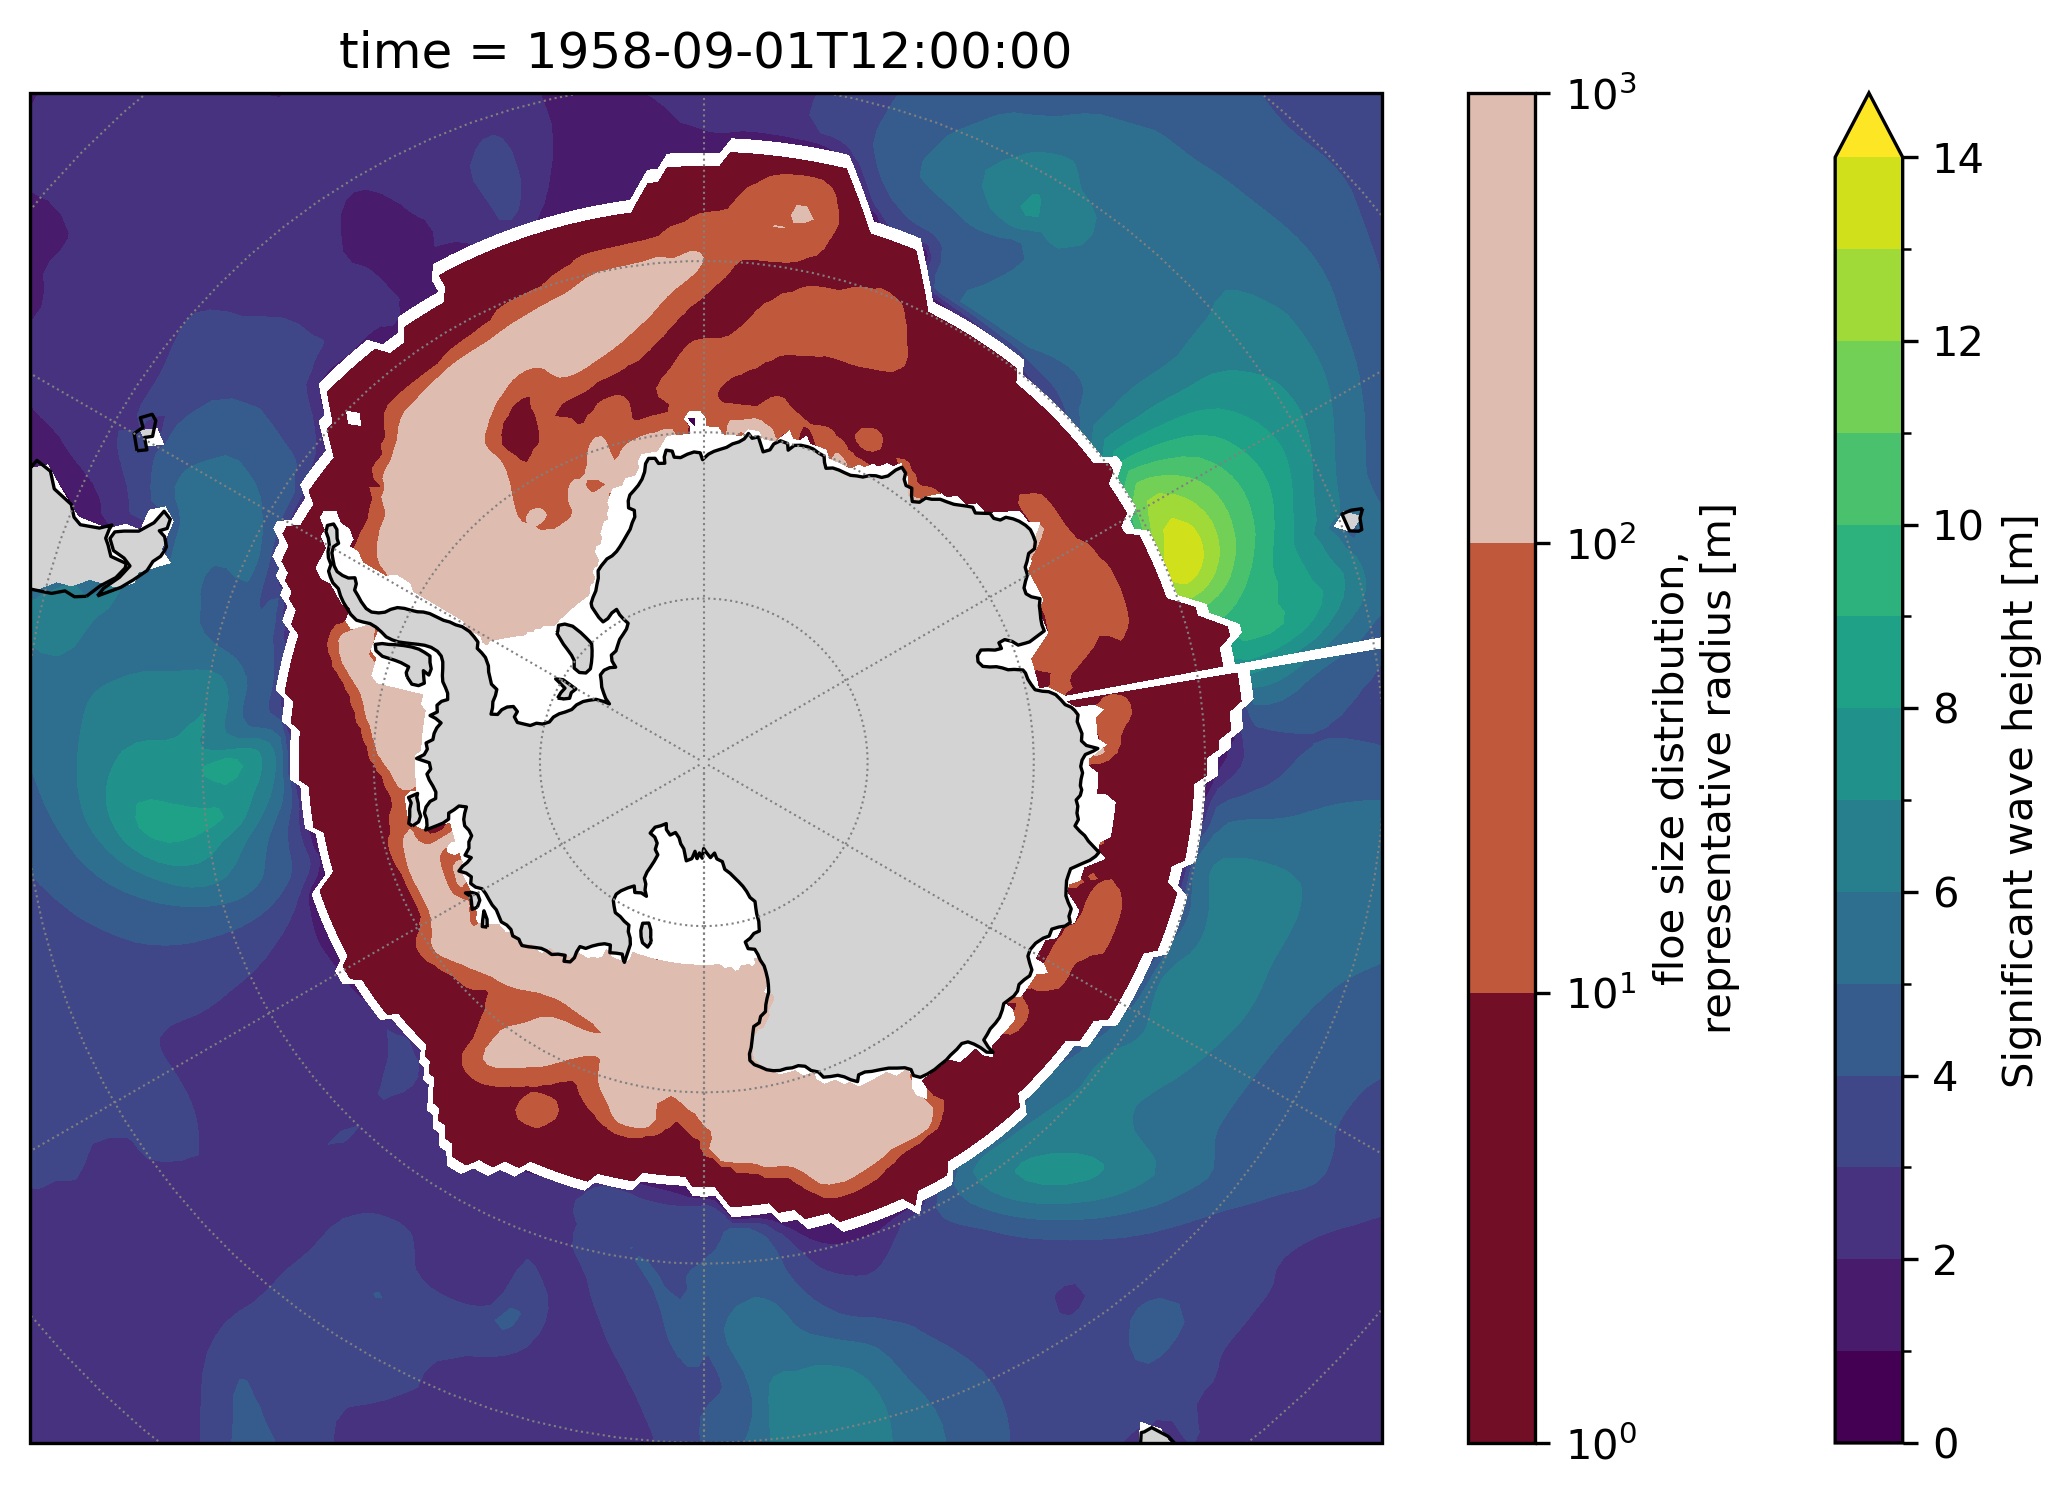

In [88]:
import matplotlib.colors as mcolors

fig, ax = make_fig_antarctica(central_longitude=0)

swh_daily.where(aice_daily < 0.15).plot.contourf(
    ax=ax,
    levels=15,
    vmax=14,
    transform=ccrs.PlateCarree()
)
# axes[0].set_title('WW3')

fsdrad_daily.where(aice_daily > 0.15).plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    # levels = np.logspace(0.1, np.log10(1000), 8),
    norm=mcolors.LogNorm(vmin=1, vmax=1000),
    # vmin=0,
    # vmax=800,
    cmap=cm.cm.amp_r
)


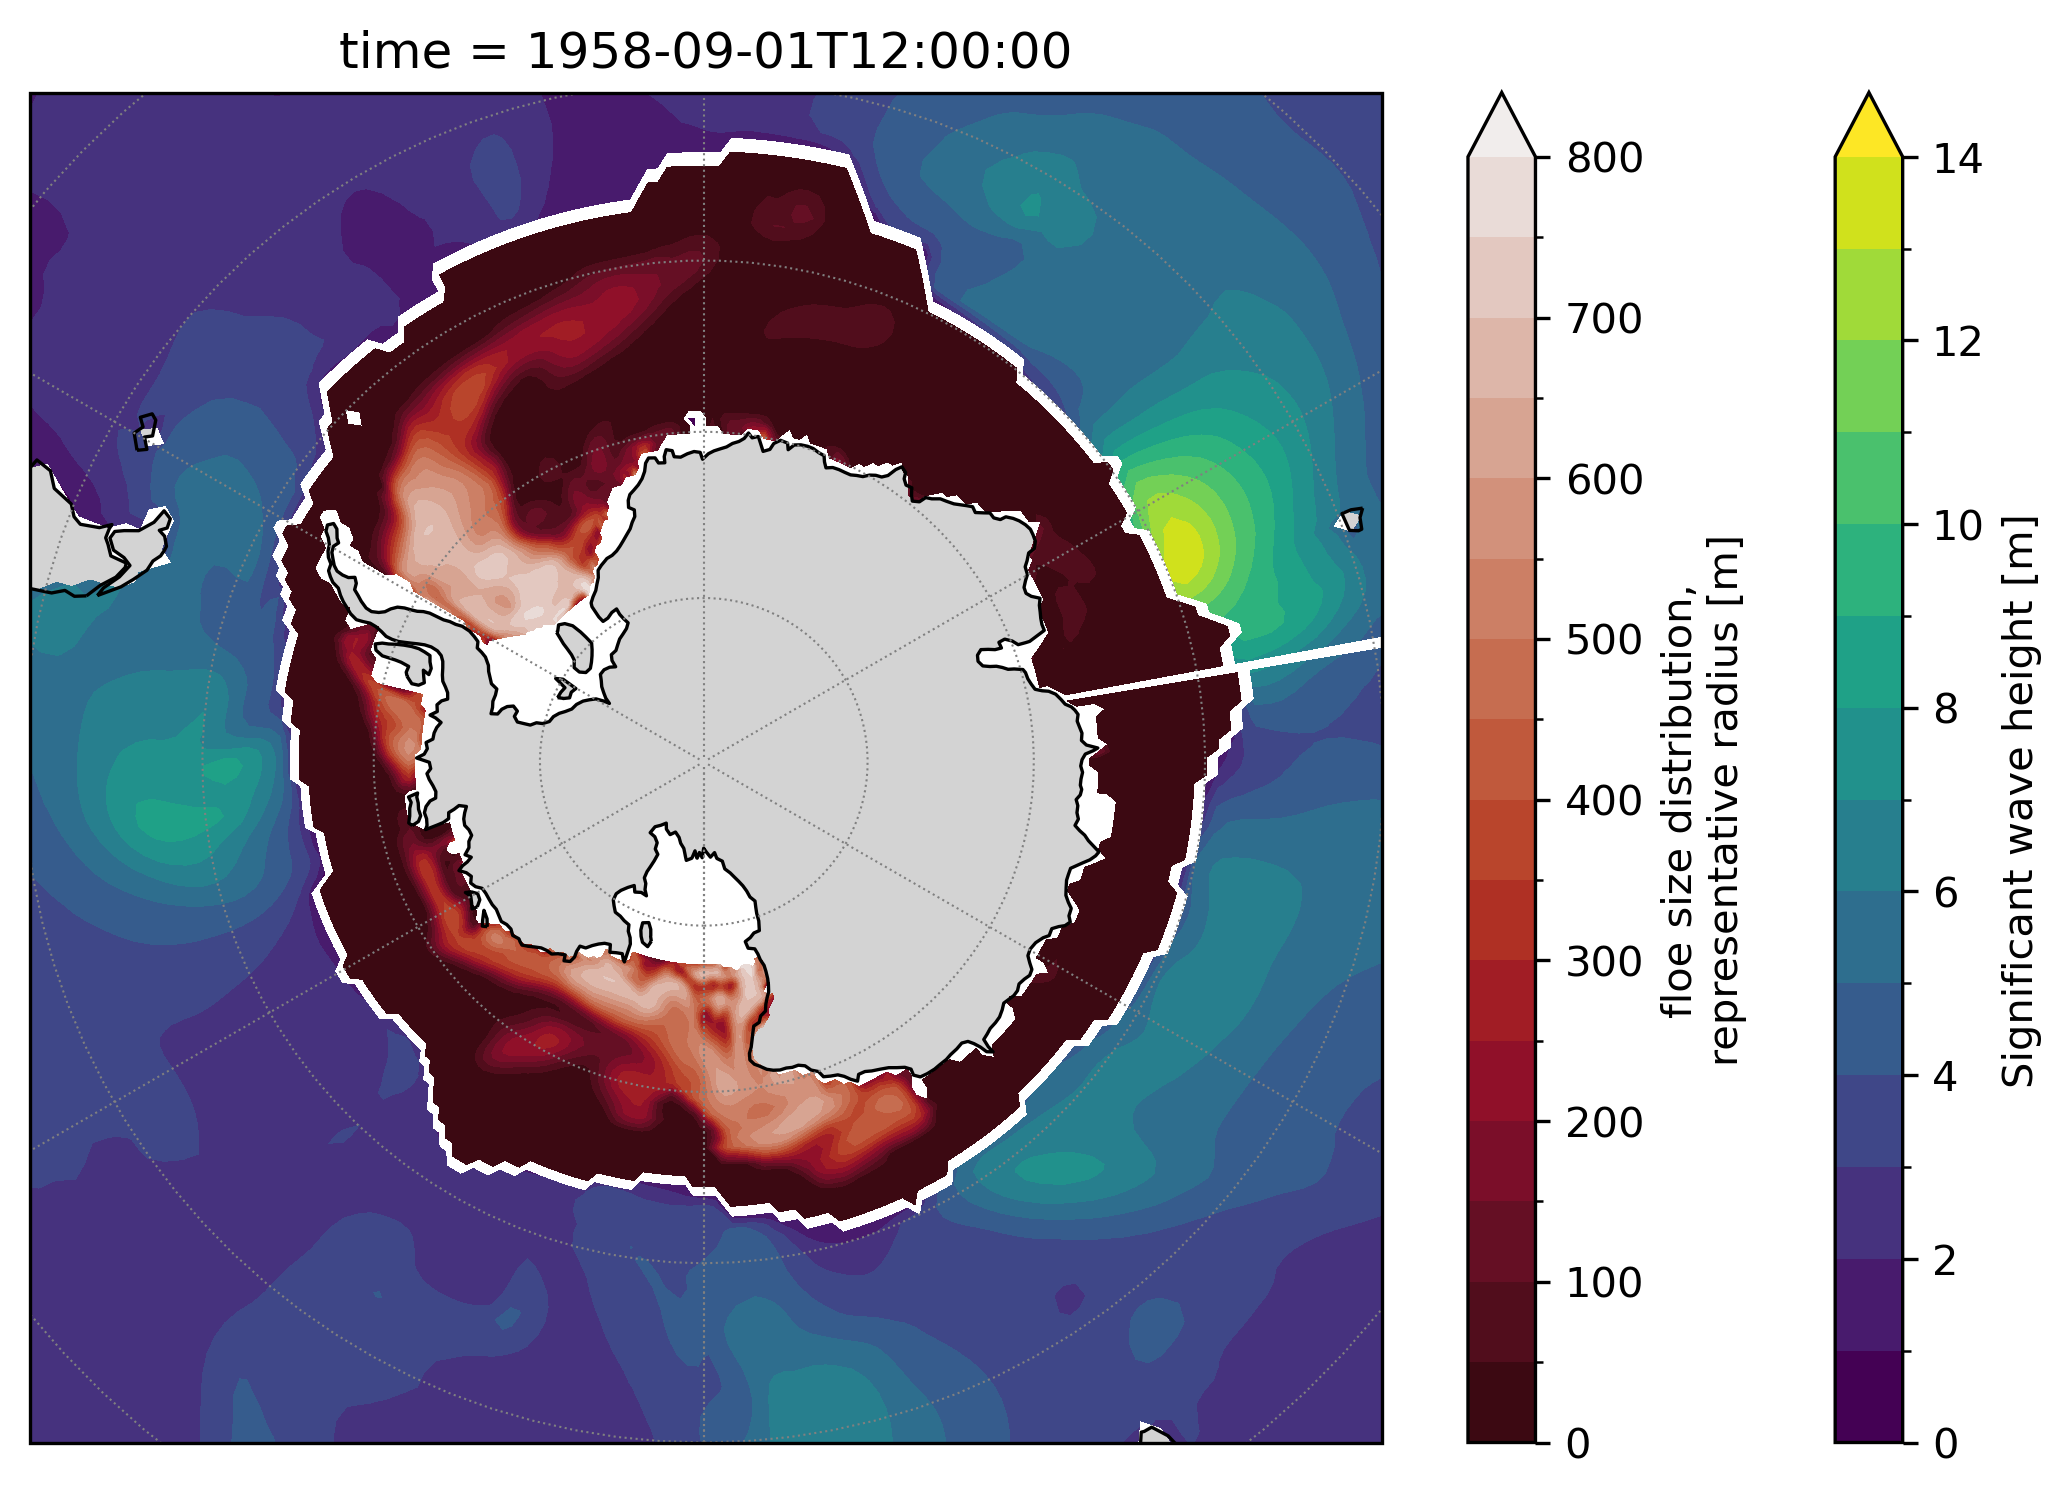

In [84]:
import matplotlib.colors as mcolors

fig, ax = make_fig_antarctica(central_longitude=0)

swh_daily.where(aice_daily < 0.15).plot.contourf(
    ax=ax,
    levels=15,
    vmax=14,
    transform=ccrs.PlateCarree()
)
# axes[0].set_title('WW3')

fsdrad_daily.where(aice_daily > 0.15).plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels = 17,
    # norm=mcolors.LogNorm(vmin=0.1, vmax=1000),
    vmin=0,
    vmax=800,
    cmap=cm.cm.amp_r
)
